# Workshop: Tunix-Med · Part 4 — Final Evaluation & Proof of Knowledge

This is the payoff notebook. We load the LoRA adapter trained in Part 3, merge it back into the base model, and run exactly the same evaluation pipeline as Part 2. The numerical comparison between baseline and fine-tuned scores is the **proof of knowledge** that the workshop aims to demonstrate.

---

## What this notebook demonstrates

| Claim | How we prove it |
|-------|-----------------|
| The model learned cardiology-specific terminology | Keyword F1 improvement |
| The model generates more semantically correct answers | Semantic score improvement |
| The model produces clinically accurate responses | AI Judge score improvement |
| The model internalised domain language patterns | Corpus PPL reduction |

Because the test set is **reconstructed identically** (same seed, same split logic as Part 2), any score change is attributable solely to the fine-tuning, not to a different question sample.

---

## The JAX → PyTorch bridge

One non-obvious challenge in this workflow is that training happened in **JAX/Flax** (Part 3, via Tunix) but evaluation uses the standard **PyTorch/Transformers/PEFT** stack. These two ecosystems use different weight matrix conventions, which requires a careful transposition step when loading the adapter. The `load_peft_adapter_from_tunix` function handles this transparently.


## 1 · Load Fine-Tuned Model

The loading procedure has three stages:
1. **Detect the adapter source** — prefer the locally trained adapter from `tunix-medical-model/` (the output directory of notebook 03); fall back to the Hugging Face Hub if it does not exist.
2. **Fix the weight layout** — apply smart transposition to correct the JAX→PyTorch convention mismatch.
3. **Merge and unload** — fold the LoRA $\Delta W$ back into the base weights so the model behaves like a standard PyTorch `AutoModelForCausalLM`, with no PEFT overhead at inference time.

After `merge_and_unload()`, the model has the same architecture and memory footprint as the original base model — the only difference is that its weights now incorporate the fine-tuning signal.


### Deep Dive: Bridging the JAX → PyTorch Weight Layout

#### The root cause
JAX and PyTorch follow different conventions for storing linear layer weights:

| Framework | LoRA $A$ shape | LoRA $B$ shape |
|-----------|----------------|----------------|
| JAX (Tunix) | `(in_features, rank)` | `(rank, out_features)` |
| PyTorch (PEFT) | `(rank, in_features)` | `(out_features, rank)` |

When Tunix exported the adapter in Part 3, the `.T` transpose was applied before saving. However, if the adapter was saved with an older version of the export code, or if the shapes were not correctly detected at save time, the tensors may still be in JAX layout. The `load_peft_adapter_from_tunix` function handles both cases:

#### Smart transposition
Rather than blindly transposing all tensors, we **detect the layout** by comparing the actual tensor shape against the rank declared in `adapter_config.json`:
- For `lora_A`: if `tensor.shape[0] != rank`, the tensor is in JAX layout `(in, rank)` and must be transposed to `(rank, in)`.
- For `lora_B`: if `tensor.shape[1] != rank`, the tensor is in JAX layout `(rank, out)` and must be transposed to `(out, rank)`.

This is safe because LoRA matrices are always non-square (rank is typically 8–64, far smaller than `in_features` which is 1024–4096).

#### `.contiguous()` and the safetensors requirement
PyTorch’s `.T` operator does **not** copy memory — it returns a *view* with a modified stride pattern. The `safetensors` library requires tensors to be stored in **C-contiguous order** (row-major, no stride gaps). Calling `.contiguous()` after `.T` forces a physical memory reorder, making the tensor safe to serialise.

#### The temporary directory trick
PEFT’s `from_pretrained` expects a directory with both `adapter_config.json` and `adapter_model.safetensors`. We write the fixed tensors to a `tempfile.mkdtemp()` directory, load from there, then delete the directory. This avoids modifying the original saved adapter.


In [1]:
import os
import shutil
import tempfile
import warnings
import logging
import math
import json

import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import safetensors.torch as sft_torch

warnings.filterwarnings("ignore")
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def info_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = info_device()
dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
    else torch.float32
)
print(f"Device: {device}  |  dtype: {dtype}")

BASE_MODEL = "google/gemma-3-270m-it"
MODEL_KEY = BASE_MODEL.split("/")[1]
LOCAL_ADAPTER = "tunix-medical-model"  # output dir from notebook 03
HUB_ADAPTER = f"lmassaron/{MODEL_KEY}-medical-cardiology-lora"

# Prefer locally trained adapter; fall back to the Hub
_adapter_source = LOCAL_ADAPTER if os.path.isdir(LOCAL_ADAPTER) else HUB_ADAPTER
print(f"Adapter source : {_adapter_source}")


def load_peft_adapter_from_tunix(base_model, adapter_source):
    import huggingface_hub

    if os.path.isdir(adapter_source):
        st_file = os.path.join(adapter_source, "adapter_model.safetensors")
        cfg_file = os.path.join(adapter_source, "adapter_config.json")
    else:
        print(f"  Downloading adapter from Hub: {adapter_source}")
        st_file = huggingface_hub.hf_hub_download(
            adapter_source, "adapter_model.safetensors"
        )
        cfg_file = huggingface_hub.hf_hub_download(
            adapter_source, "adapter_config.json"
        )

    with open(cfg_file, "r") as f:
        peft_config = json.load(f)
    rank = peft_config.get("r")

    tmp_dir = tempfile.mkdtemp(prefix="peft_fixed_")
    shutil.copy(cfg_file, os.path.join(tmp_dir, "adapter_config.json"))

    raw, fixed, n_fixed = sft_torch.load_file(st_file, device="cpu"), {}, 0
    # Smart Transposition: detect JAX layout (in, rank) vs PyTorch (rank, in)
    for key, tensor in raw.items():
        if "lora_A" in key and tensor.shape[0] != rank:
            fixed[key] = tensor.T.contiguous()  # (in, rank) -> (rank, in)
            n_fixed += 1
        elif "lora_B" in key and tensor.shape[1] != rank:
            fixed[key] = tensor.T.contiguous()  # (rank, out) -> (out, rank)
            n_fixed += 1
        else:
            fixed[key] = tensor
    
    if n_fixed > 0:
        print(f"  Auto-fixed {n_fixed} LoRA tensors (JAX -> PyTorch layout)")
    
    sft_torch.save_file(fixed, os.path.join(tmp_dir, "adapter_model.safetensors"))

    peft_model = PeftModel.from_pretrained(base_model, tmp_dir)
    shutil.rmtree(tmp_dir, ignore_errors=True)
    return peft_model


print(f"Loading base model {BASE_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=dtype,
    device_map="auto",
)

print("Merging LoRA adapter ...")
model = load_peft_adapter_from_tunix(base_model, _adapter_source)
model = model.merge_and_unload()
model.eval()
print("Fine-tuned model merged and ready.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu130).
/home/lmassaron/code/gde-tpu-sprint-2026/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


Device: cuda  |  dtype: torch.bfloat16
Adapter source : tunix-medical-model
Loading base model google/gemma-3-270m-it ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Merging LoRA adapter ...



WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 6.0.3+d539aeb
Transformers : 5.5.4
Torch        : 2.10.0+cu130
Triton       : 3.6.0


Fine-tuned model merged and ready.


## 2 · Reconstructing the Test Set

This cell is **identical** to the sampling code in notebook 02, intentionally. We use the same:
- `DATASET_ID`, `EVAL_SPLIT`, `SEED`, and `N_EVAL_QS` constants.
- The same two-RNG pattern (`rng` for train/eval split, `rng2` for within-eval sampling).
- The same deduplication heuristic (first four words of the question as a prefix key).

This reproducibility is what makes the Part 2 ↔ Part 4 comparison valid. If we used a different sample, improvements in metrics could reflect an easier question set rather than a more capable model.

> **Why reconstruct rather than load from CSV?** Loading the saved `medical_baseline_results.csv` would give us the questions, but we also need the raw `dataset_idx` values to pull fresh examples from the HuggingFace dataset object for inference. Reconstructing ensures all fields are available without depending on the CSV’s column set.


In [2]:
DATASET_ID, EVAL_SPLIT, SEED, N_EVAL_QS = (
    "lmassaron/medical-cardiology-qa",
    0.1,
    42,
    100,
)
full_ds = load_dataset(DATASET_ID, split="train")
rng = np.random.default_rng(SEED)
all_idx = rng.permutation(len(full_ds))
eval_idx = all_idx[int(len(full_ds) * (1.0 - EVAL_SPLIT)) :]


def extract_qa(example):
    msgs = example["messages"]
    return {
        "question": next(m["content"] for m in msgs if m["role"] == "user"),
        "answer": next(m["content"] for m in msgs if m["role"] == "assistant"),
    }


rng2, seen_prefixes, qa_pairs = np.random.default_rng(SEED + 1), set(), []
for idx in rng2.permutation(eval_idx):
    if len(qa_pairs) >= N_EVAL_QS:
        break
    ex = extract_qa(full_ds[int(idx)])
    q, a = ex["question"], ex["answer"]
    if len(a) < 25:
        continue
    prefix = " ".join(q.lower().split()[:4])
    if prefix in seen_prefixes:
        continue
    seen_prefixes.add(prefix)
    qa_pairs.append({"question": q, "answer": a, "dataset_idx": int(idx)})

data = pd.DataFrame(qa_pairs)
print(f"Sampled {len(data)} questions for final testing.")

Sampled 100 questions for final testing.


## 3 · Final Inference & Corpus Perplexity

The inference loop is structurally identical to notebook 02 with one key difference: the fine-tuned model is allowed to generate **up to 300 tokens** (vs 256 for the baseline), reflecting that a more capable model may produce longer, more detailed clinical answers.

Two forward passes per example:
1. **Generation** — greedy decoding with `repetition_penalty=1.1`. We expect the fine-tuned model to produce more domain-specific answers with fewer “I’m happy to help” non-answers.
2. **Perplexity** — masked loss on the ground-truth assistant turn. The corpus-level PPL accumulation is identical to Part 2, enabling a direct numerical comparison.

Both the generated text and the per-example perplexity are stored in `results_df` for downstream scoring and distribution plotting.


### Deep Dive: What Perplexity Reveals About Fine-Tuning Quality

#### Expected PPL behaviour after SFT
A successful fine-tuning run should show:
- **Training PPL** drops to 3–10 (model memorises training answers).
- **Validation PPL** drops to 8–15 (generalisation to held-out answers).
- **Evaluation PPL** (this notebook) drops vs. baseline, confirming domain adaptation.

If training PPL is very low (≤3) but evaluation PPL barely improves, the model has **overfit** — it memorised training examples without learning transferable domain knowledge. The LoRA rank and dropout settings in Part 3 are specifically tuned to prevent this.

#### Corpus PPL vs. per-example PPL distribution
We track both:
- **Corpus PPL** (single scalar) — the headline number for headline comparison.
- **Per-example PPL** (one per question) — stored in `results_df['perplexity']` for distribution plots in Section 5. A healthy fine-tuned model should shift the entire distribution left (lower PPL), not just pull down a few outliers.

#### The `min(loss_i, 20.0)` clamp
Cross-entropy loss can be arbitrarily large for out-of-distribution sequences (e.g., $L = 50$ → PPL $= e^{50} \approx 5 \times 10^{21}$). Clamping at 20 caps PPL at $e^{20} \approx 485{,}165{,}195$, preventing numerical overflow from skewing the per-example distribution chart without affecting the corpus-level metric (which uses raw accumulated bits).


In [3]:
SYSTEM_PROMPT = (
    "You are a knowledgeable medical assistant specializing in cardiology. "
    "Answer clinical questions accurately, focusing on diagnostic criteria, "
    "treatment guidelines, and pathophysiology."
)
results_list = []

total_loss_bits = 0.0
total_tokens = 0

for _, row in tqdm(data.iterrows(), total=len(data), desc="Tuned Inference"):
    question = row["question"]
    answer = row["answer"]

    # 1. Generation
    encoded = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    prompt_len = encoded["input_ids"].shape[-1]

    with torch.no_grad():
        out_gen = model.generate(
            **encoded,
            max_new_tokens=300,
            min_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,
        )

    gen_text = tokenizer.decode(out_gen[0, prompt_len:], skip_special_tokens=True).strip()

    # 2. Perplexity (True Corpus PPL)
    full_ids_ppl = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer},
        ],
        return_tensors="pt",
        return_dict=True,
    )["input_ids"].to(device)

    labels = full_ids_ppl.clone()
    labels[:, :prompt_len] = -100

    with torch.no_grad():
        out_loss = model(full_ids_ppl, labels=labels)
        loss_i = out_loss.loss.item()

    n_answer_tokens = (labels != -100).sum().item()
    total_loss_bits += loss_i * n_answer_tokens
    total_tokens += n_answer_tokens

    # Per-example perplexity (kept for distribution charts)
    perplexity_i = math.exp(min(loss_i, 20.0))

    results_list.append(
        {
            "question": question,
            "expected_answer": answer,
            "generated_answer": gen_text,
            "perplexity": perplexity_i,
        }
    )

results_df = pd.DataFrame(results_list)
corpus_ppl = math.exp(total_loss_bits / total_tokens)
print(f"Inference complete. Corpus Perplexity: {corpus_ppl:.2f}")

Tuned Inference:   0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Inference complete. Corpus Perplexity: 8.45


## 4 · Scoring

This section applies the same three-metric scoring pipeline as notebook 02. Every function, parameter, and model choice is intentionally identical:

- **Keyword F1** (`keyword_f1_tfidf`): same TF-IDF vectoriser fitted on reference answers, same 4-character minimum word length filter, same weighted F1 formula.
- **Semantic similarity** (`_raw_semantic`): same `all-MiniLM-L6-v2` encoder, same min-max normalisation within the batch.
- **AI Judge** (`ai_judge`): same Qwen 2.5 7B model, same 4-bit NF4 quantisation, same prompt and rubric.
- **Final score**: same weighted sum (10% keyword + 30% semantic + 60% AI Judge).

Consistency here is critical — any change to the scoring pipeline would confound the comparison with the baseline. The only variable between Part 2 and Part 4 is the model.

> **Scoring pipeline split across multiple cells**: keyword and semantic scoring are lightweight (no GPU needed beyond the sentence encoder) and run first. The AI Judge requires loading a separate 7B model, so it is placed in its own cell to make GPU memory management explicit and the cell execution order clear.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

_tfidf = TfidfVectorizer(
    analyzer="word", token_pattern=r"\b\w{4,}\b", sublinear_tf=True
)
_tfidf.fit(results_df["expected_answer"].tolist())
_vocab = _tfidf.vocabulary_
_idf = _tfidf.idf_


def keyword_f1_tfidf(generated: str, expected: str) -> float:
    ref_kws = set(re.findall(r"\b\w{4,}\b", expected.lower()))
    gen_kws = set(re.findall(r"\b\w{4,}\b", generated.lower()))
    if not ref_kws:
        return 1.0

    def weighted_count(kws, universe):
        return sum(
            _idf[_vocab[w]] if w in _vocab else 1.0 for w in universe if w in kws
        )

    ref_weight = sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in ref_kws)
    gen_weight = (
        sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in gen_kws)
        if gen_kws
        else 0.0
    )

    if ref_weight == 0 or gen_weight == 0:
        return 0.0
    recall = weighted_count(gen_kws, ref_kws) / ref_weight
    precision = weighted_count(ref_kws, gen_kws) / gen_weight
    return float(
        (2 * precision * recall / (precision + recall))
        if (precision + recall) > 0
        else 0.0
    )

In [5]:
from sentence_transformers import SentenceTransformer, util

sim_model = SentenceTransformer("all-MiniLM-L6-v2")


def _raw_semantic(generated: str, expected: str) -> float:
    e1 = sim_model.encode(generated, convert_to_tensor=True, show_progress_bar=False)
    e2 = sim_model.encode(expected, convert_to_tensor=True, show_progress_bar=False)
    return float(util.pytorch_cos_sim(e1, e2))

INFO:sentence_transformers.base.model:No device provided, using cuda:0
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
from transformers import BitsAndBytesConfig

JUDGE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
judge_tok = AutoTokenizer.from_pretrained(JUDGE_MODEL)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=dtype,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

judge_mdl = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL, quantization_config=bnb_config, device_map="auto"
)


def ai_judge(question: str, generated: str, expected: str) -> float:
    prompt = (
        "You are an expert clinical cardiologist and medical education evaluator.\n"
        "Evaluate the 'Generated Answer' against the 'Reference Answer' for the given 'Question'.\n\n"
        "### SCORING RUBRIC (1-10):\n"
        "- 1: NO ANSWER (e.g., greetings, refusals, 'I am ready to help') or COMPLETELY WRONG.\n"
        "- 2-4: MAJOR ERRORS (significant inaccuracies or misses the key point).\n"
        "- 5-6: PARTIALLY CORRECT (covers some aspects but lacks depth or minor inaccuracies).\n"
        "- 7-8: MOSTLY CORRECT (aligns with the reference, but slightly incomplete or verbose).\n"
        "- 9-10: EXCELLENT (clinically precise, factual, accurate, and matches or improves on the reference).\n\n"
        "### INSTRUCTIONS:\n"
        "1. Penalize non-answers or conversational fluff with a score of 1.\n"
        "2. Score ONLY the medical accuracy and clinical relevance.\n"
        "3. Ignore chatbot niceties (e.g., 'I hope this helps').\n"
        "4. First write reasoning, then on the last line write ONLY: 'Score: [number]'\n\n"
        f"Question: {question}\n"
        f"Reference Answer: {expected}\n"
        f"Generated Answer: {generated}\n"
    )

    inp = judge_tok.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(judge_mdl.device)

    with torch.no_grad():
        out = judge_mdl.generate(**inp, max_new_tokens=150, do_sample=False)

    txt = judge_tok.decode(
        out[0, inp["input_ids"].shape[-1] :], skip_special_tokens=True
    ).strip()
    
    # Improved extraction: look for "Score: X" on the last few lines
    lines = txt.splitlines()
    for line in reversed(lines):
        m = re.search(r"Score:\s*(\d+)", line)
        if m:
            return max(min(int(m.group(1)) / 10.0, 1.0), 0.1)
            
    # Fallback
    m = re.search(r"\b(\d+)\b", txt.splitlines()[-1])
    return max(min((int(m.group(1)) / 10.0) if m else 0.5, 1.0), 0.1)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [7]:
results_df["keyword_score"] = results_df.apply(
    lambda r: keyword_f1_tfidf(r["generated_answer"], r["expected_answer"]), axis=1
)
results_df["_raw_sim"] = results_df.apply(
    lambda r: _raw_semantic(r["generated_answer"], r["expected_answer"]), axis=1
)

sim_min, sim_max = results_df["_raw_sim"].min(), results_df["_raw_sim"].max()
results_df["semantic_score"] = (
    (results_df["_raw_sim"] - sim_min) / (sim_max - sim_min)
).clip(0, 1)

In [8]:
print("Running AI Judge (may take a few minutes)...")
scores = []
for _, r in tqdm(results_df.iterrows(), total=len(results_df), desc="AI Judge"):
    score = ai_judge(r["question"], r["generated_answer"], r["expected_answer"])
    scores.append(score)
results_df["ai_judge_score"] = scores

results_df["final_score"] = (
    results_df["keyword_score"] * 0.1
    + results_df["semantic_score"] * 0.3
    + results_df["ai_judge_score"] * 0.6
)

print("\n--- FINAL EVALUATION RESULTS ---")
print(f"  Mean Keyword Score  : {results_df['keyword_score'].mean():.3f}")
print(f"  Mean Semantic Score : {results_df['semantic_score'].mean():.3f}")
print(f"  Mean AI Judge Score : {results_df['ai_judge_score'].mean():.3f}")
print(f"  Mean Final Score    : {results_df['final_score'].mean():.3f}")
print(f"  Corpus Perplexity   : {corpus_ppl:.2f}")
print("---------------------------------")

results_df.to_csv("medical_final_results.csv", index=False)

Running AI Judge (may take a few minutes)...


AI Judge:   0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- FINAL EVALUATION RESULTS ---
  Mean Keyword Score  : 0.240
  Mean Semantic Score : 0.650
  Mean AI Judge Score : 0.411
  Mean Final Score    : 0.466
  Corpus Perplexity   : 8.45
---------------------------------


## 5 · Workshop Results Summary

This section produces the definitive comparison of the workshop. If `medical_baseline_results.csv` exists (saved by notebook 02), we overlay the baseline and fine-tuned score distributions on the same axes.

### How to read the comparison plots

Each of the five panels shows a histogram for one metric. The x-axis is the score value (0–1 for most metrics; raw PPL for perplexity). A rightward shift (blue → coral) for score metrics and a leftward shift for perplexity both indicate improvement.

| Metric | Healthy improvement pattern |
|--------|----------------------------|
| Keyword F1 | Distribution shifts right; mass below 0.3 decreases |
| Semantic | Distribution shifts right; mode closer to 1.0 |
| AI Judge | Distribution shifts right; mass at 0.1 (score 1/10) decreases |
| Final Score | Composite shift right |
| Perplexity | Distribution shifts left; long right tail (high PPL) shrinks |

Beyond the aggregate means printed in Part 4’s scoring cell, the distributional view reveals whether improvement is broad (all questions improve slightly) or narrow (a few questions improve dramatically while others regress). A broad improvement indicates genuine domain adaptation; a narrow one may suggest overfitting to specific question types in the training set.


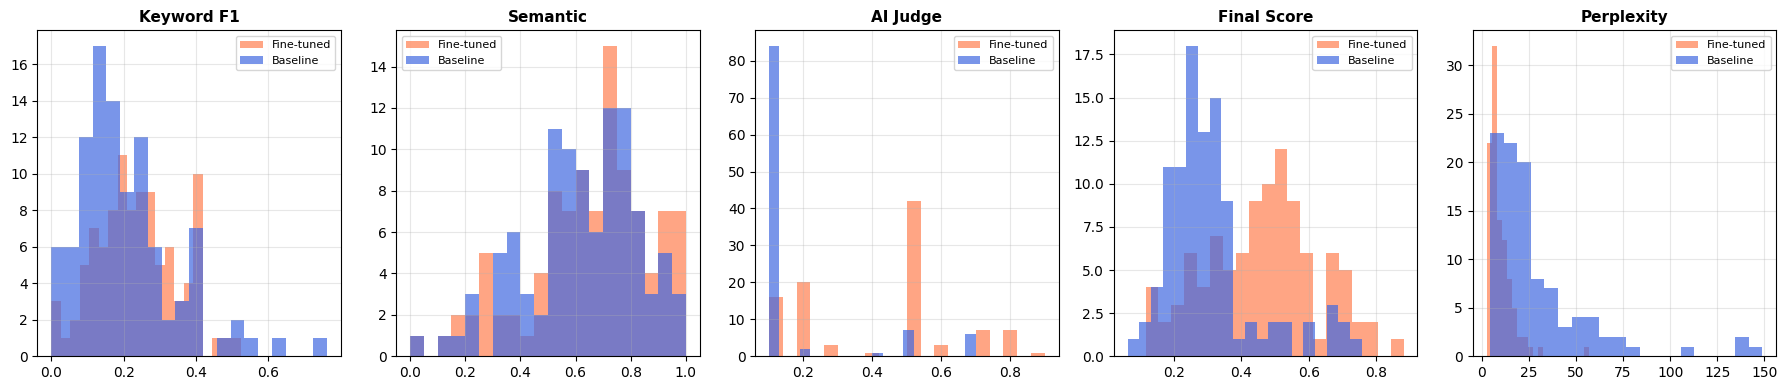

In [9]:
import matplotlib.pyplot as plt

if os.path.exists("medical_baseline_results.csv"):
    base_df = pd.read_csv("medical_baseline_results.csv")
    has_baseline = True
else:
    has_baseline = False

metrics = [
    "keyword_score",
    "semantic_score",
    "ai_judge_score",
    "final_score",
    "perplexity",
]
labels = ["Keyword F1", "Semantic", "AI Judge", "Final Score", "Perplexity"]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
for ax, col, label in zip(axes, metrics, labels):
    vals_ft = results_df[col]
    ax.hist(vals_ft, bins=20, alpha=0.7, color="coral", label="Fine-tuned")
    if has_baseline and col in base_df.columns:
        ax.hist(base_df[col], bins=20, alpha=0.7, color="royalblue", label="Baseline")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("final_evaluation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Qualitative Analysis: Best & Worst Performers

Inspecting individual examples is the final step of the evaluation and often the most revealing. Aggregate metrics can hide important failure patterns that only become visible when reading actual model outputs.

### What to look for in the fine-tuned examples

**Top performers** (highest AI Judge scores) should show:
- Correct use of cardiology-specific terminology introduced during fine-tuning.
- Structured, clinically organised answers (e.g., “differential diagnosis, investigations, management”).
- Fewer conversational fillers (“I’m happy to help”, “Great question”) that scored 1/10 in the baseline.

**Bottom performers** (lowest AI Judge scores after fine-tuning) reveal the **residual gap**:
- Questions requiring very specific numerical thresholds (drug doses, cut-off values) that may not have appeared frequently enough in the 90-question training set.
- Highly ambiguous questions where even the reference answer is debatable.
- Cases where the model over-applies domain knowledge and produces verbose but off-target answers.

Comparing the bottom performers here against the bottom performers from Part 2 shows whether fine-tuning addressed the specific failure modes identified in the baseline, or whether a different set of weaknesses has emerged.


In [10]:
def display_examples(df, title, n=3, ascending=False):
    header = "=" * 80
    divider = "-" * 80
    print(f"\n{header}\n{title}\n{header}")
    subset = df.sort_values("ai_judge_score", ascending=ascending).head(n)
    for i, (_, row) in enumerate(subset.iterrows()):
        print(f"\n[{i+1}] Score: {row['ai_judge_score']:.1f} | Question: {row['question']}")
        print(f"\nGenerated Answer:\n{row['generated_answer']}")
        print(f"\nReference Answer:\n{row['expected_answer']}")
        print(f"\n{divider}")

display_examples(results_df, "TOP 3 PERFORMING EXAMPLES (Fine-Tuned)", n=3, ascending=False)
display_examples(results_df, "BOTTOM 3 PERFORMING EXAMPLES (Fine-Tuned)", n=3, ascending=True)



TOP 3 PERFORMING EXAMPLES (Fine-Tuned)

[1] Score: 0.9 | Question: What are the primary prevention measures for atherosclerosis?

Generated Answer:
The primary prevention of atherosclerosis involves managing risk factors and lifestyle modifications to reduce the likelihood of plaque formation. These include dietary changes, regular physical activity, smoking cessation, and controlling blood pressure. Lifestyle modifications also play a crucial role in preventing atherosclerosis by reducing cholesterol levels and improving overall cardiovascular health.

Reference Answer:
Primary prevention of atherosclerosis includes controlling risk factors such as promoting healthy eating, increasing physical activity, managing hypertension, treating diabetes, avoiding smoking, and controlling cholesterol levels.

--------------------------------------------------------------------------------

[2] Score: 0.8 | Question: What is the risk of untreated abnormal heart rhythms in Brugada syndrome?

Gene